# Wavelength-dependent acceptance model

This notebook reproduces the wavelength-dependent quantum-efficiency and glass-transmission interpolations used by the P-ONE PMT acceptance model. Their product is the spectral component of the photon-detection probability; it does not include angular acceptance, collection efficiency, or photon weight.

In [7]:
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib-kbas"

import matplotlib.pyplot as plt
import numpy as np

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import c, elementary_charge, h
from scipy.interpolate import CubicSpline, LinearNDInterpolator


def find_workspace_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / 'pone_offline/data/qe.csv').is_file():
            return candidate
    raise FileNotFoundError('Could not locate pone_offline/data/qe.csv')


workspace_root = find_workspace_root()
data_dir = workspace_root / 'pone_offline/data'
qe_path = data_dir / 'qe.csv'
glass_path = data_dir / 'glass.csv'

qe_data = np.loadtxt(qe_path, delimiter=',')
glass_data = np.loadtxt(glass_path, delimiter=',')

# qe.csv stores photon energy (eV) and quantum efficiency.
energy_ev = qe_data[:, 0]
qe_values = qe_data[:, 1]
wavelength_qe_nm = (h * c / elementary_charge) / energy_ev * 1e9
qe_order = np.argsort(wavelength_qe_nm)
wavelength_qe_nm = wavelength_qe_nm[qe_order]
qe_values = qe_values[qe_order]

# glass.csv stores wavelength (nm) and transmission.
wavelength_glass_nm = glass_data[:, 0]
glass_values = glass_data[:, 1]
glass_order = np.argsort(wavelength_glass_nm)
wavelength_glass_nm = wavelength_glass_nm[glass_order]
glass_values = glass_values[glass_order]

# Match the CubicSpline interpolation used in PMTAcceptance.py.
qe_spline = CubicSpline(wavelength_qe_nm, qe_values, extrapolate=False)
glass_spline = CubicSpline(wavelength_glass_nm, glass_values, extrapolate=False)

wavelength_min = max(wavelength_qe_nm.min(), wavelength_glass_nm.min())
wavelength_max = min(wavelength_qe_nm.max(), wavelength_glass_nm.max())
wavelength_nm = np.linspace(wavelength_min, wavelength_max, 1000)

qe = qe_spline(wavelength_nm)
glass_transmission = glass_spline(wavelength_nm)
combined_efficiency = qe * glass_transmission

print(f'QE range: {wavelength_qe_nm.min():.1f}--{wavelength_qe_nm.max():.1f} nm')
print(f'Glass range: {wavelength_glass_nm.min():.1f}--{wavelength_glass_nm.max():.1f} nm')
print(f'Common plotted range: {wavelength_min:.1f}--{wavelength_max:.1f} nm')

QE range: 275.9--720.1 nm
Glass range: 300.6--699.4 nm
Common plotted range: 300.6--699.4 nm


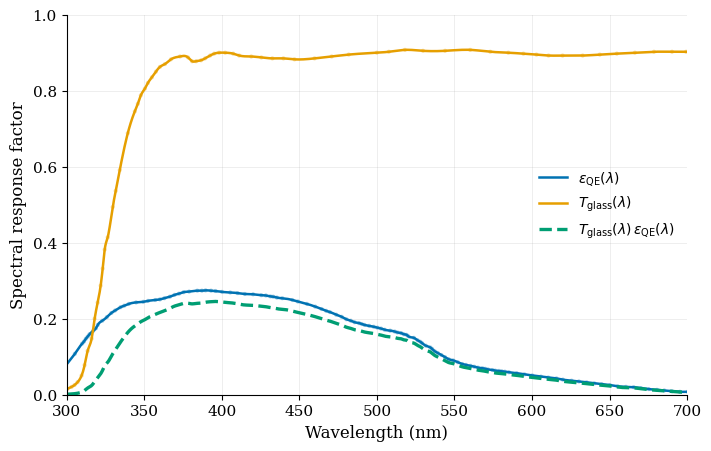

In [9]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
})

fig, ax = plt.subplots(figsize=(7.0, 4.4), constrained_layout=True)

ax.plot(wavelength_nm, qe, color='#0072B2', lw=1.8,
        label=r'$\epsilon_{\mathrm{QE}}(\lambda)$')
ax.plot(wavelength_nm, glass_transmission, color='#E69F00', lw=1.8,
        label=r'$T_{\mathrm{glass}}(\lambda)$')
ax.plot(wavelength_nm, combined_efficiency, color='#009E73', lw=2.4, ls='--',
        label=r'$T_{\mathrm{glass}}(\lambda)\,\epsilon_{\mathrm{QE}}(\lambda)$')

ax.scatter(wavelength_qe_nm, qe_values, s=9, color='#0072B2', alpha=0.35,
           edgecolors='none')
ax.scatter(wavelength_glass_nm, glass_values, s=9, color='#E69F00', alpha=0.35,
           edgecolors='none')

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Spectral response factor')
ax.set_xlim(300, 700)
ax.set_xticks(np.arange(300, 701, 50))
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.grid(alpha=0.22, linewidth=0.7)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

output_stem = Path.cwd() / 'spectral_detection_efficiency'
fig.savefig(output_stem.with_suffix('.pdf'), bbox_inches='tight', pad_inches=0.03)
plt.show()

## Angular acceptance

The angular-acceptance surface below reproduces the two-dimensional interpolation used by the PMT-acceptance model as a function of effective transverse distance and photon incidence angle.

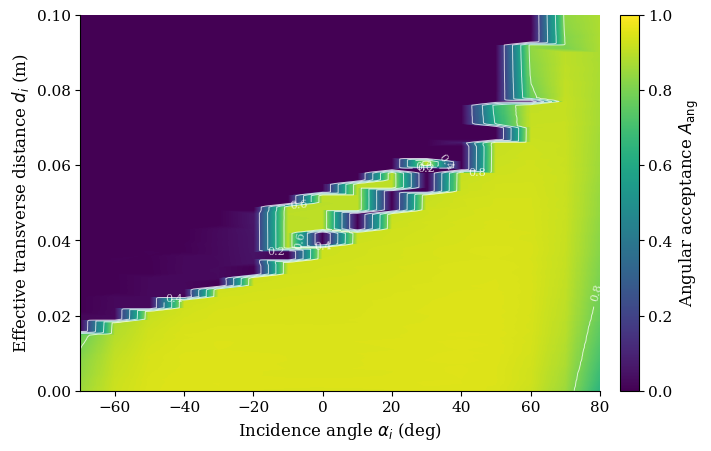

In [10]:
angular_path = data_dir / 'Angular_Acceptance.txt'
angular_data = np.loadtxt(angular_path, delimiter=',')

distance_data = angular_data[:, 0]
angle_data = angular_data[:, 1]
acceptance_data = angular_data[:, 2]

# Match the LinearNDInterpolator used in PMTAcceptance.py.
angular_interpolator = LinearNDInterpolator(
    np.column_stack((distance_data, angle_data)),
    acceptance_data,
)

angle_grid = np.linspace(angle_data.min(), angle_data.max(), 500)
distance_grid = np.linspace(distance_data.min(), distance_data.max(), 400)
angle_mesh, distance_mesh = np.meshgrid(angle_grid, distance_grid)
angular_acceptance = angular_interpolator(distance_mesh, angle_mesh)
# The simulation converts values outside the interpolation domain to zero.
angular_acceptance = np.nan_to_num(angular_acceptance, nan=0.0)

fig, ax = plt.subplots(figsize=(7.0, 4.4), constrained_layout=True)
mesh = ax.pcolormesh(
    angle_mesh,
    distance_mesh,
    angular_acceptance,
    shading='auto',
    cmap='viridis',
    vmin=0,
    vmax=1,
    rasterized=True,
)

contours = ax.contour(
    angle_mesh,
    distance_mesh,
    angular_acceptance,
    levels=[0.2, 0.4, 0.6, 0.8],
    colors='white',
    linewidths=0.7,
    alpha=0.75,
)
ax.clabel(contours, fmt='%.1f', fontsize=8, inline=True)

colorbar = fig.colorbar(mesh, ax=ax, pad=0.02)
colorbar.set_label(r'Angular acceptance $A_{\mathrm{ang}}$')

ax.set_xlabel(r'Incidence angle $\alpha_i$ (deg)')
ax.set_ylabel(r'Effective transverse distance $d_i$ (m)')
ax.set_xlim(angle_data.min(), angle_data.max())
ax.set_ylim(distance_data.min(), distance_data.max())
ax.spines[['top', 'right']].set_visible(False)

output_path = Path.cwd() / 'angular_acceptance.pdf'
fig.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.03)
plt.show()